Wrote train_augmented.csv and test_augmented.csv

   time         A         B         C         D         E         F         G  \
0     0  0.207366 -0.159951 -0.634176 -0.580962 -0.266505  0.060173 -0.475257   
1     1  0.188828 -0.265508  0.042143 -0.550442 -0.132319 -0.185219  0.028295   
2     2 -0.144261 -0.577142 -0.214634 -0.747391 -0.184255 -0.464831 -0.085181   
3     3  0.208982 -0.310449  0.513708 -0.562868  0.742308 -0.305487  0.762246   
4     4  0.093320 -0.358156  0.173188 -0.687296 -0.161461 -0.116062 -0.245748   

          H         I         J         K         L         M         N  \
0 -1.486516 -0.332594 -0.671466 -0.226149 -0.187624 -0.780237 -0.785965   
1  0.093210 -0.518139 -0.251917 -0.347845 -0.359069 -0.161254  0.020401   
2  0.700449 -0.603438  0.197773 -0.566696 -0.580799  0.202726  0.135261   
3  1.363020 -0.384575  0.525556 -0.348514 -0.428099  0.548993  0.471031   
4  0.863372 -0.655588 -0.263358 -0.557428 -0.481214  0.083602  0.003087   

         Y1 

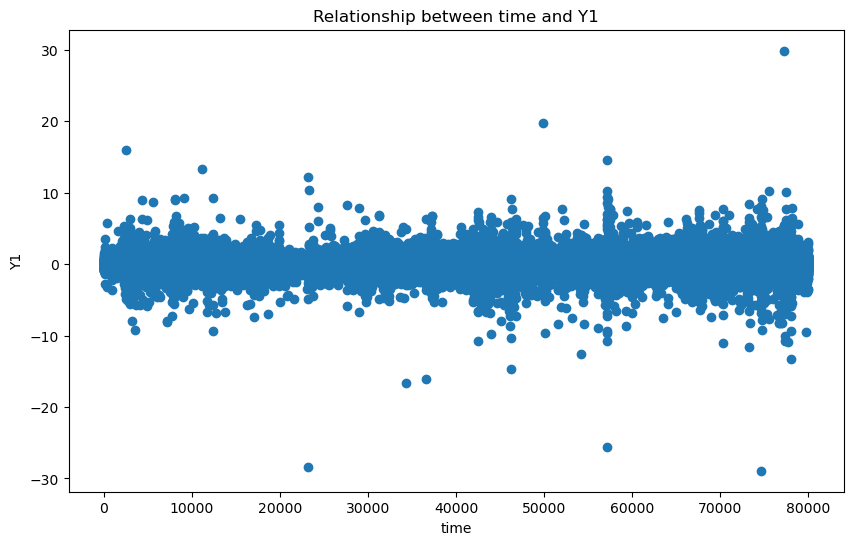

Correlation between time and Y1 = -0.0056


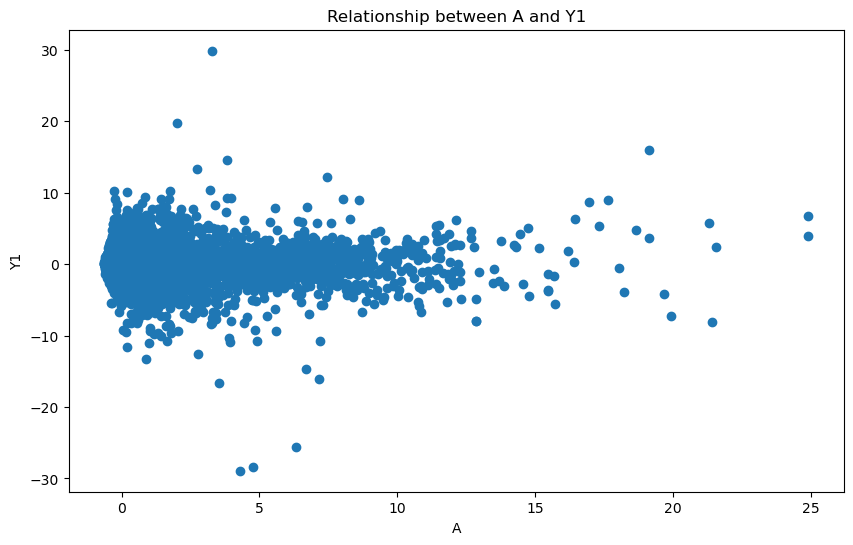

Correlation between A and Y1 = -0.0061


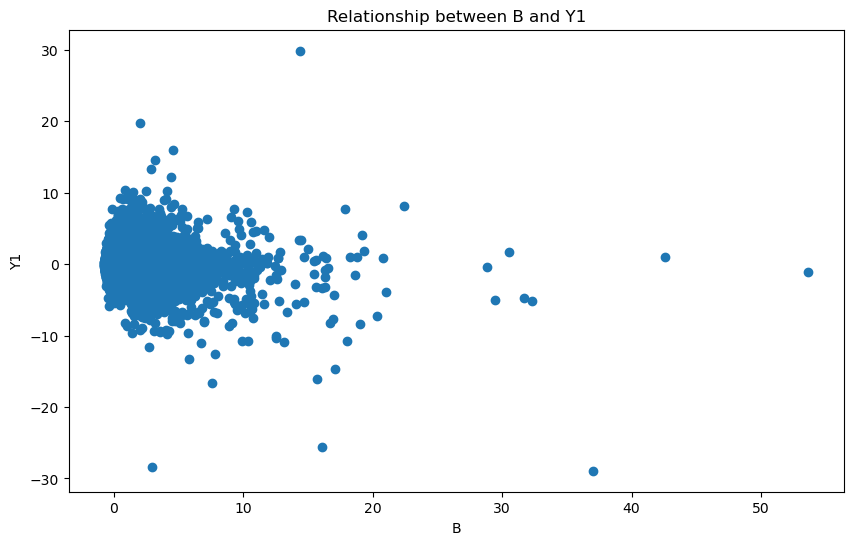

Correlation between B and Y1 = -0.0950


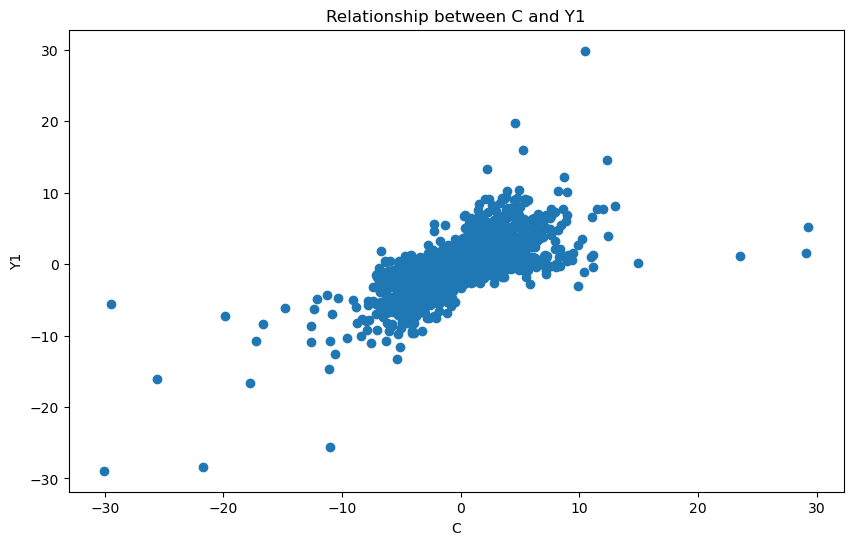

Correlation between C and Y1 = 0.7038


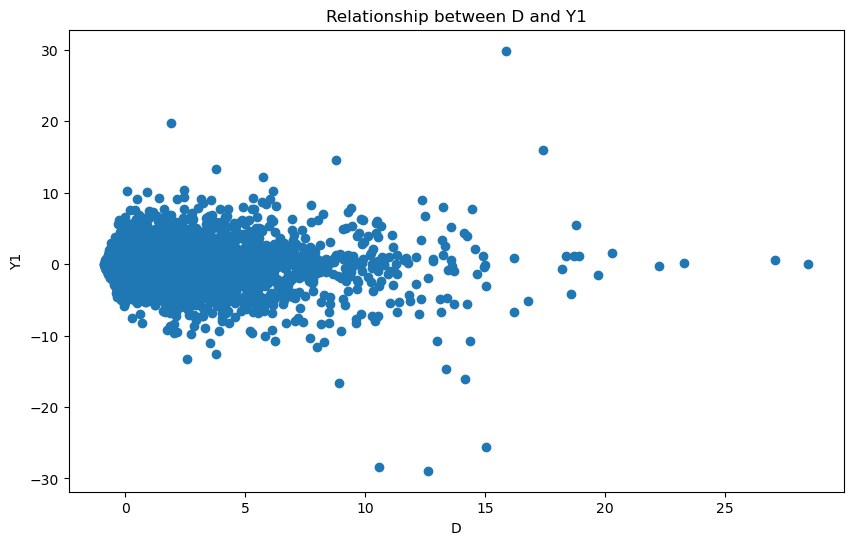

Correlation between D and Y1 = -0.0571


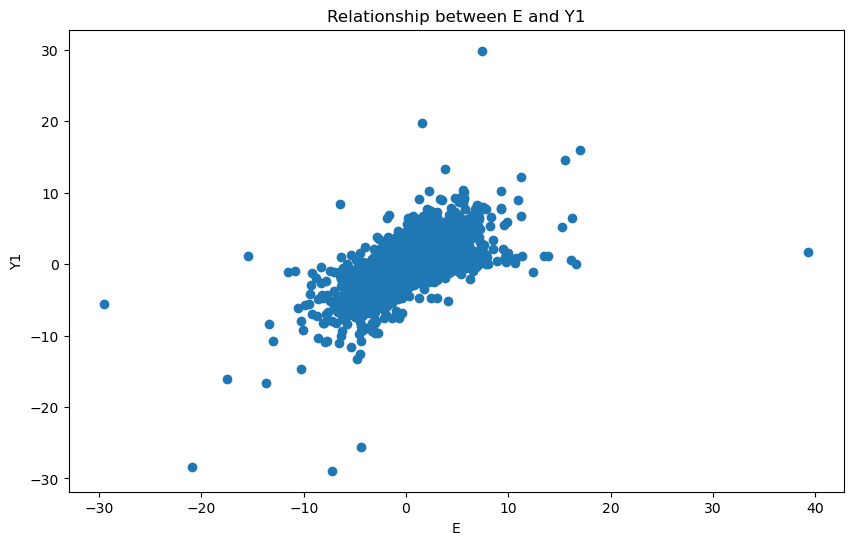

Correlation between E and Y1 = 0.6843


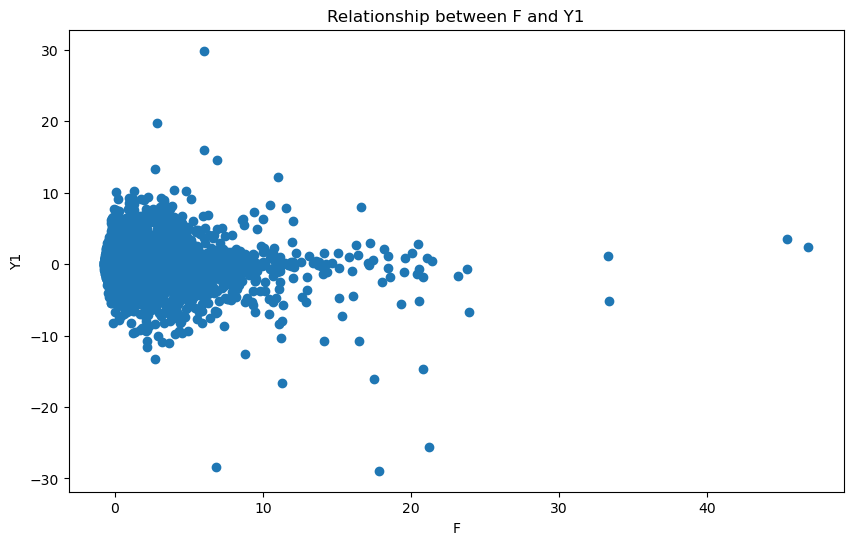

Correlation between F and Y1 = -0.0732


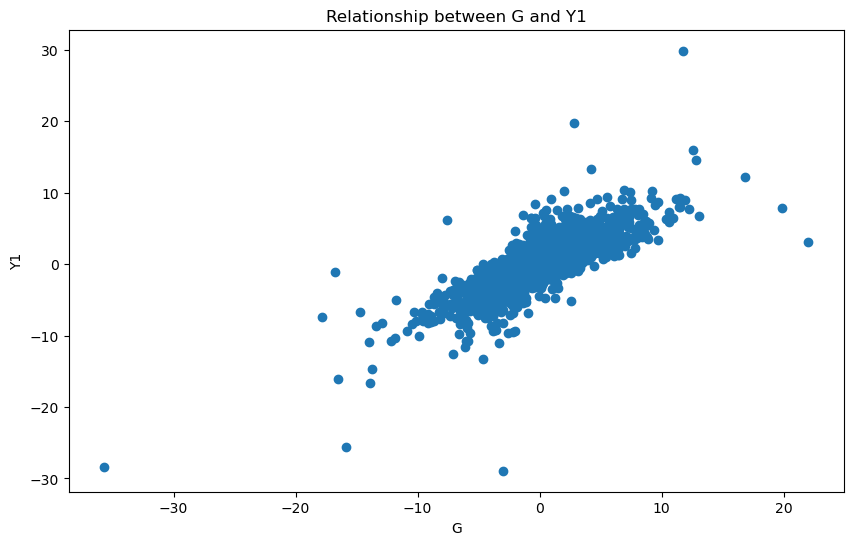

Correlation between G and Y1 = 0.8146


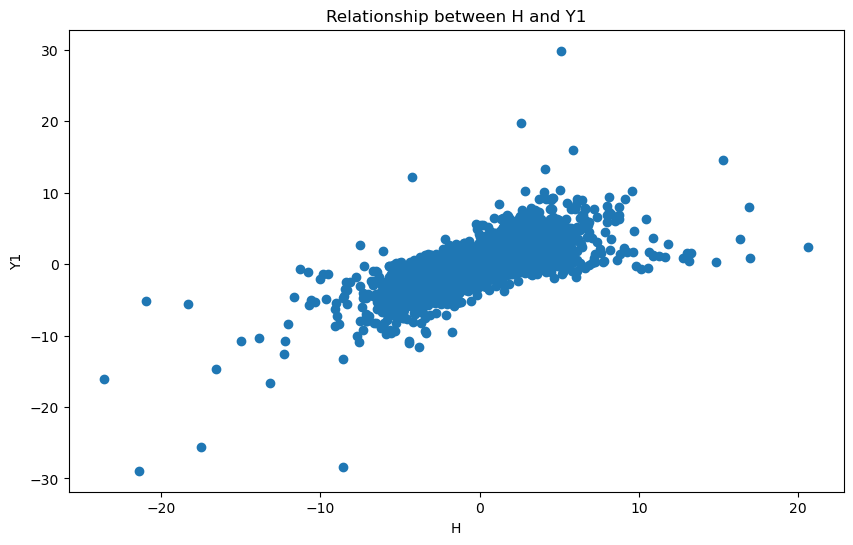

Correlation between H and Y1 = 0.7076


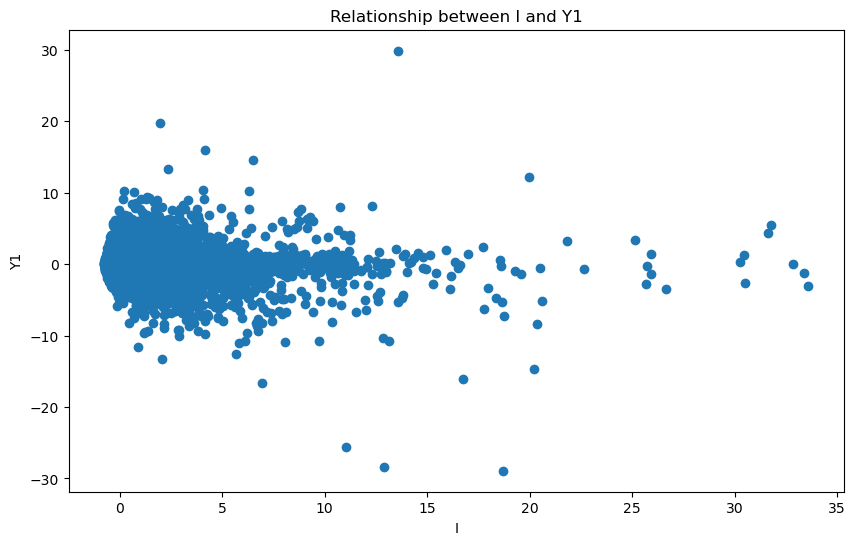

Correlation between I and Y1 = -0.0902


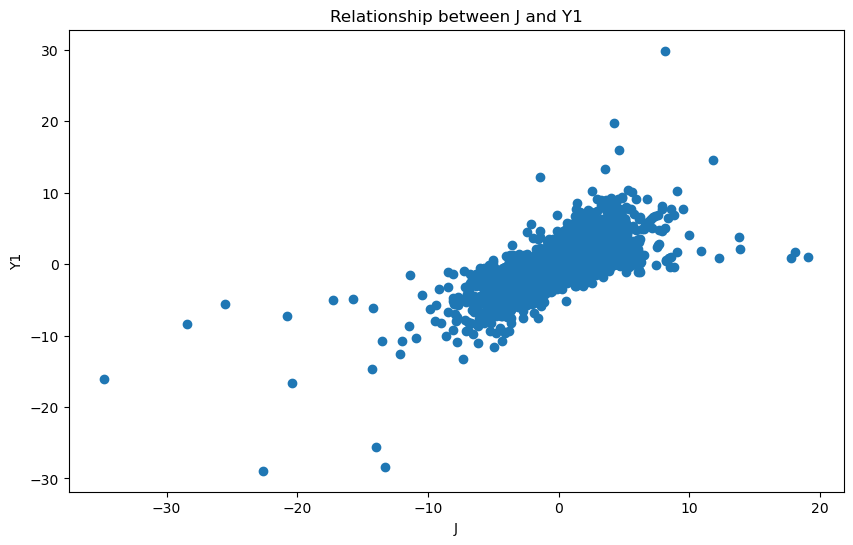

Correlation between J and Y1 = 0.7239


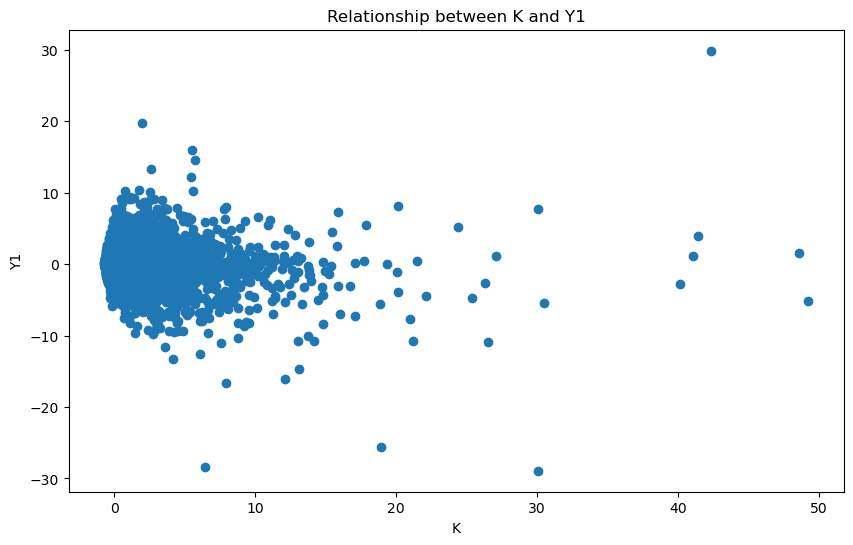

Correlation between K and Y1 = -0.0802


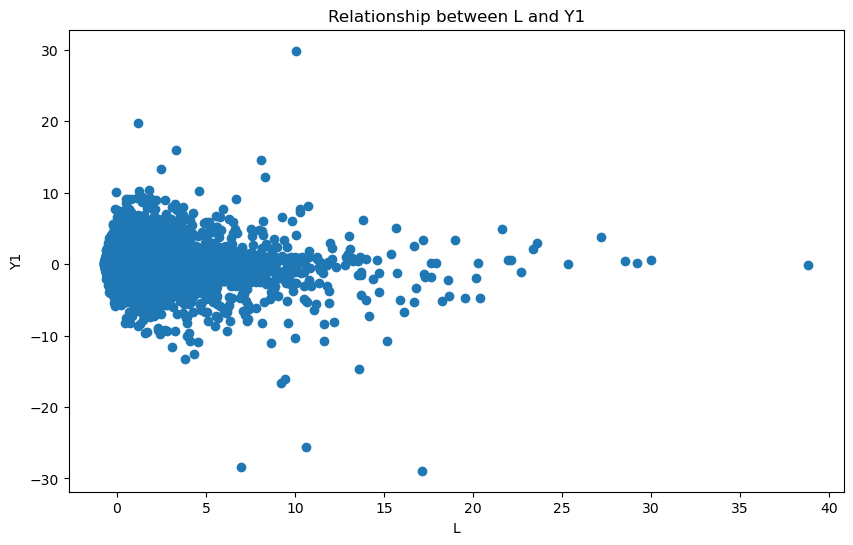

Correlation between L and Y1 = -0.0724


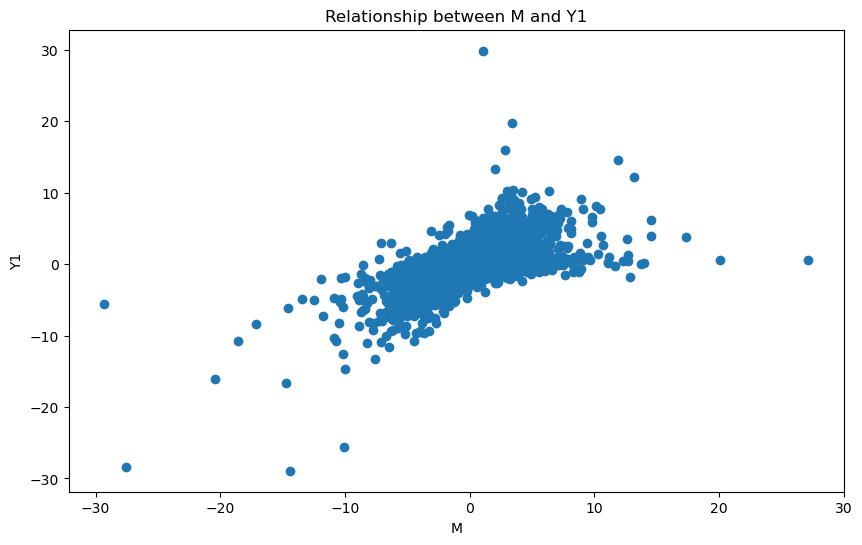

Correlation between M and Y1 = 0.6862


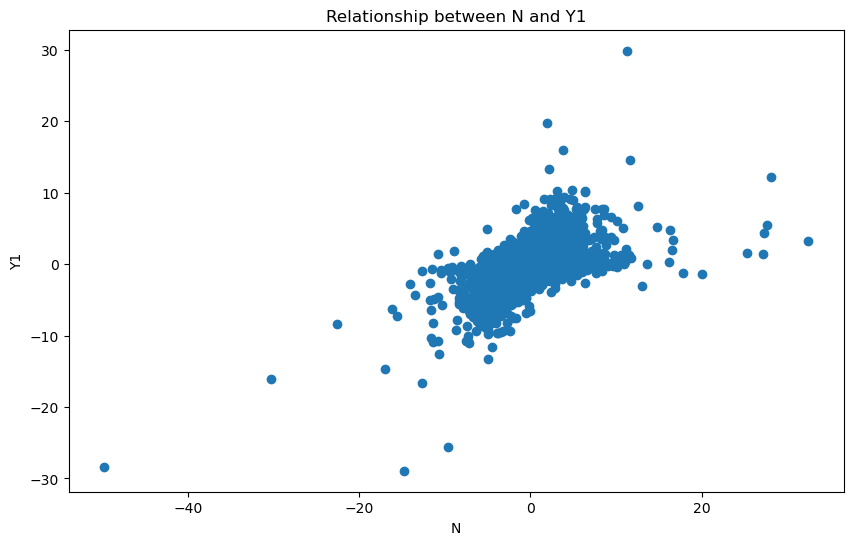

Correlation between N and Y1 = 0.5958


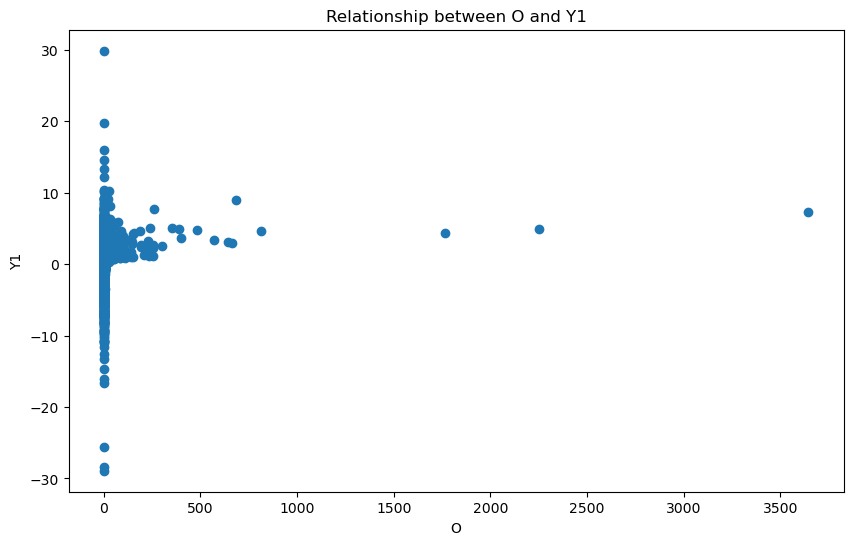

Correlation between O and Y1 = 0.0776


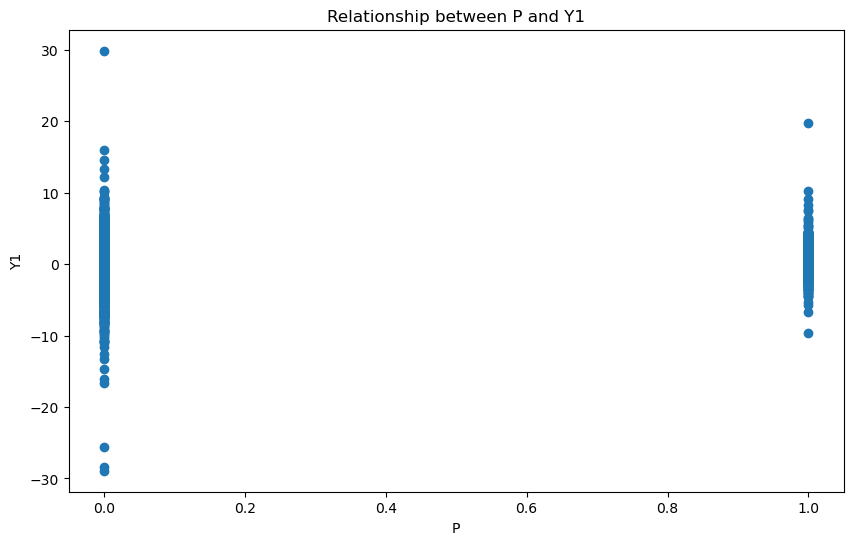

Correlation between P and Y1 = 0.0300

Sorted Correlation Table:
   Quantity  Correlation with Y1
7         G             0.814568
10        J             0.723921
8         H             0.707560
3         C             0.703823
13        M             0.686246
5         E             0.684297
14        N             0.595766
15        O             0.077631
16        P             0.030019
0      time            -0.005645
1         A            -0.006105
4         D            -0.057097
12        L            -0.072366
6         F            -0.073191
11        K            -0.080196
9         I            -0.090226
2         B            -0.094995

R^2 for Y1 =  0.7751933514155235
R^2 for Y2 =  0.7877520027486992
Final averaged R^2 score =  0.7814726770821113

Predictions Saved.


In [ ]:
# Code for Market Research Section of QuantChallenge 2025

# initially reading the training data and test data CSV files

import pandas as pd
import os
from pathlib import Path

train_base = Path('/Users/hridimab/Library/CloudStorage/OneDrive-Personal/Documents/My Files/University/QuantChallenge2025/quantchallenge-starter/data/train.csv')
test_base = Path('/Users/hridimab/Library/CloudStorage/OneDrive-Personal/Documents/My Files/University/QuantChallenge2025/quantchallenge-starter/data/test.csv')

train_extra = Path('/Users/hridimab/Library/CloudStorage/OneDrive-Personal/Documents/My Files/University/QuantChallenge2025/quantchallenge-starter/data/train_new.csv')
test_extra = Path('/Users/hridimab/Library/CloudStorage/OneDrive-Personal/Documents/My Files/University/QuantChallenge2025/quantchallenge-starter/data/test_new.csv')

train_df = pd.read_csv(train_base)
test_df = pd.read_csv(test_base)
train_new_columns = pd.read_csv(train_extra, usecols=['O', 'P'])
test_new_columns = pd.read_csv(test_extra, usecols=['O', 'P'])

assert len(train_df) == len(train_new_columns)
assert len(test_df) == len(test_new_columns)

train_augmented = pd.concat([train_df.reset_index(drop=True),
                        train_new_columns.reset_index(drop=True)], axis=1)
test_augmented = pd.concat([test_df.reset_index(drop=True),
                        test_new_columns.reset_index(drop=True)], axis=1)

for c in ['O', 'P']:
    med = train_augmented[c].median()
    train_augmented[c] = train_augmented[c].fillna(med)
    test_augmented[c] = test_augmented[c].fillna(med)

train_augmented.to_csv("train_augmented.csv", index=False)
test_augmented.to_csv("test_augmented.csv", index=False)

print("Wrote train_augmented.csv and test_augmented.csv")
print('')

train_data = pd.read_csv("train_augmented.csv")
test_data = pd.read_csv("test_augmented.csv")

print(train_data.head())
print(test_data.head())

# plotting scatter graphs of the columns vs Y1

import matplotlib.pyplot as plt

for col in train_data.columns:
    if col not in ['Y1', 'Y2']:
        plt.figure(figsize=(10, 6))
        plt.scatter(train_data[col], train_data['Y1'])
        plt.xlabel(col)
        plt.ylabel('Y1')
        plt.title('Relationship between ' + col + ' and Y1')
        plt.show()

        #calculating the correlations
    
        correlation = train_data[col].corr(train_data['Y1'])
        print(f"Correlation between {col} and Y1 = {correlation:.4f}")

# putting the correlations into a sorted table

correlations = (
    train_data.drop(columns=['Y2'])
    .corr()['Y1']
    .drop('Y1')
)
correlation_table = correlations.reset_index()
correlation_table.columns = ['Quantity', 'Correlation with Y1']
correlation_table = correlation_table.sort_values(
    by=f'Correlation with Y1', ascending=False
)
print('')
print('Sorted Correlation Table:')
print(correlation_table)
print('')

# prediction model

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

USE_Y_STANDARDIZATION = True

train_sorted = train_data.sort_values('time').reset_index(drop=True)

quantity_columns = [c for c in train_sorted.columns if c not in ['Y1', 'Y2']]
X_all = train_sorted[quantity_columns]
X_all = train_sorted[['Y1', 'Y2']].to_numpy()
#y1_all = train_sorted['Y1']
#y2_all = train_sorted['Y2']

rf = make_pipeline(
    SimpleImputer(strategy='median')
    RandomForestRegressor(
        n_estimators=600,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    )
)

#model = MultiOutputRegressor(base_reg)

tscv = TimeSeriesSplit(n_splits=5)
r2_y1_scores, r2_y2_scores = [], []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_all), start=1):
    X_train, X_val = X_all.iloc[tr_idx], X_all.iloc[va_idx]
    y1_train, y1_val = y1_all.iloc[tr_idx], y1_all.iloc[va_idx]
    y2_train, y2_val = y2_all.iloc[tr_idx], y2_all.iloc[va_idx]

quantity_columns_test = [c for c in test_data.columns if c!= 'id']
X_test = test_data[quantity_columns_test]

X = train_data.drop(columns=['Y1', 'Y2'])
y1 = train_data['Y1']
y2 = train_data['Y2']

X_train, X_val, y1_train, y1_val, y2_train, y2_val = train_test_split(
    X, y1, y2, test_size=0.2, random_state=42
)

# model for Y1
model_y1 = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model_y1.fit(X_train, y1_train)
y1_pred_val = model_y1.predict(X_val)
r2_y1 = r2_score(y1_val, y1_pred_val)
print('R^2 for Y1 = ', r2_y1)

# model for Y2
model_y2 = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model_y2.fit(X_train, y2_train)
y2_pred_val = model_y2.predict(X_val)
r2_y2 = r2_score(y2_val, y2_pred_val)
print('R^2 for Y2 = ', r2_y2)

# final score

r2_y1_scores.append(r2_y1)
r2_y2_scores.append(r2_y2)

model_y1_final = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_all, y1_all)
model_y2_final = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_all, y2_all)

mean_r2_y1 = np.mean(r2_y1_scores)
mean_r2_y2 = np.mean(r2_y2_scores)
final_score = (mean_r2_y1 + mean_r2_y2)/2
print('Final averaged R^2 score = ', final_score)
print('')

# predictions

X_test = test_data[[c for c in test_data.columns if c != 'id']]
y1_pred_test = model_y1_final.predict(X_test)
y2_pred_test = model_y2_final.predict(X_test)

preds = test_data[['id']].copy()
preds['Y1'] = y1_pred_test
preds['Y2'] = y2_pred_test
preds.to_csv('predictions.csv', index=False)
print ('Predictions Saved.')